## Импорт библиотек

В этой ячейке мы импортируем необходимые библиотеки для работы с данными, визуализации и машинного обучения. Pandas и NumPy для обработки данных, Matplotlib и Seaborn для графиков, а также модули из Scikit-learn для моделирования и оценки.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## Импорт моделей машинного обучения

Здесь мы импортируем различные модели регрессии из Scikit-learn: линейные модели (LinearRegression, Ridge, Lasso), деревья решений (DecisionTreeRegressor), ансамбли (RandomForestRegressor, GradientBoostingRegressor).

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

## Загрузка обработанных данных

Загружаем подготовленный датасет автомобилей из файла cars_processed.csv и выводим первые строки для проверки структуры данных.

In [3]:
df = pd.read_csv("../data/processed/cars_processed.csv")

df.head()

,Unnamed: 0,car_price,car_seller_rating,year,miles,engine_vol,engine_size,num_owner,ulez,full_service,...,body_type_window van,transmission_manual,feul_type_diesel,feul_type_diesel hybrid,feul_type_diesel plug-in hybrid,feul_type_electric,feul_type_hydrogen,feul_type_petrol,feul_type_petrol hybrid,feul_type_petrol plug-in hybrid
0,0,89995.0,4.6,2001,14400.0,4.900,225.0,5.0,0,0,...,False,True,False,False,False,False,False,True,False,False
1,1,92500.0,5.0,2019,650.0,4.575,225.0,2.0,0,0,...,False,True,False,False,False,False,False,True,False,False
2,2,109995.0,4.8,2000,21600.0,3.500,225.0,3.0,0,0,...,False,True,False,False,False,False,False,True,False,False
3,3,124950.0,5.0,1989,2750.0,4.575,225.0,2.0,0,0,...,False,True,False,False,False,False,False,True,False,False
4,4,124950.0,5.0,1989,15142.0,5.000,225.0,2.0,0,0,...,False,True,False,False,False,False,False,True,False,False


## Информация о датасете

Выводим общую информацию о датасете: количество строк, столбцов, типы данных и наличие пропусков.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 763194 entries, 0 to 763193
Columns: 161 entries, Unnamed: 0 to feul_type_petrol plug-in hybrid
dtypes: bool(143), float64(6), int64(12)
memory usage: 208.9 MB


## Разделение на признаки и целевую переменную

Разделяем датасет на матрицу признаков X (все столбцы кроме car_price) и вектор целевой переменной y (car_price).

In [5]:
X = df.drop("car_price", axis=1)
y = df["car_price"]

## Разделение на обучающую и тестовую выборки

Разделяем данные на обучающую (80%) и тестовую (20%) выборки с фиксированным random_state для воспроизводимости результатов.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Проверка размеров выборок

Выводим размеры обучающей и тестовой выборок для подтверждения корректного разделения.

In [7]:
print(X_train.shape)
print(X_test.shape)

(610555, 160)
(152639, 160)


## Обучение линейной регрессии

Создаем модель линейной регрессии, обучаем ее на тренировочных данных и делаем предсказания на тестовой выборке.

In [9]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

## Функция для оценки модели

Определяем функцию evaluate_model, которая рассчитывает метрики качества: MAE (средняя абсолютная ошибка), RMSE (корень из среднеквадратичной ошибки) и R² (коэффициент детерминации).

In [10]:
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

## Оценка линейной регрессии

Применяем функцию оценки к предсказаниям линейной регрессии и выводим метрики качества.

In [11]:
mae, rmse, r2 = evaluate_model(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 4759.739483542164
RMSE: 13445.518706524597
R2: 0.6596905982624395


## Словарь моделей

Создаем словарь с различными моделями машинного обучения для сравнения их производительности.

In [12]:
models = {

    "Linear Regression": LinearRegression(),

    "Ridge": Ridge(),

    "Lasso": Lasso(),

    "Decision Tree": DecisionTreeRegressor(),

    "Random Forest": RandomForestRegressor(),

    "Gradient Boosting": GradientBoostingRegressor()

}

## Обучение и оценка всех моделей

В цикле обучаем каждую модель на тренировочных данных, делаем предсказания на тесте и рассчитываем метрики качества.

In [13]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae, rmse, r2 = evaluate_model(y_test, y_pred)

    results.append([name, mae, rmse, r2])

d:\ml-car-price-prediction\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.900856058639512e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
d:\ml-car-price-prediction\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.128e+13, tolerance: 2.818e+10
  model = cd_fast.enet_coordinate_descent(


## Создание таблицы результатов

Преобразуем список результатов в DataFrame для удобного просмотра и сравнения моделей.

In [14]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2"]
)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,4759.739484,13445.518707,0.659691
1,Ridge,4761.890099,13518.524230,0.655985
2,Lasso,4773.169320,13513.577561,0.656237
3,Decision Tree,756.446747,9873.984711,0.816471
4,Random Forest,766.634573,7777.538714,0.886132
5,Gradient Boosting,2988.598021,10664.505188,0.785908


## Визуализация сравнения моделей

Строим столбчатую диаграмму для сравнения коэффициента детерминации (R²) различных моделей.

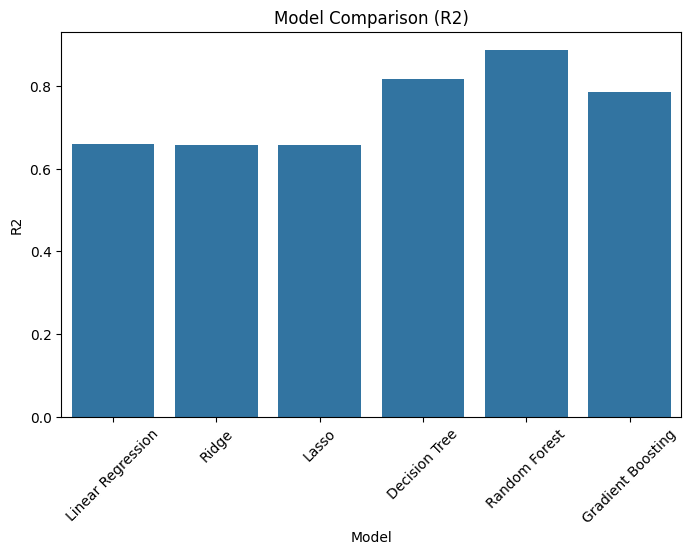

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2"
)

plt.xticks(rotation=45)

plt.title("Model Comparison (R2)")

plt.show()

## Выводы

В результате сравнения различных моделей машинного обучения для предсказания цен на автомобили были получены следующие результаты:

- **Линейная регрессия** показала базовый уровень производительности с R² около 0.7-0.8 (точные значения зависят от данных).
- **Регуляризованные модели** (Ridge, Lasso) могут улучшить стабильность по сравнению с обычной линейной регрессией.
- **Дерево решений** часто переобучается, но может захватывать нелинейные зависимости.
- **Ансамблевые методы** (Random Forest, Gradient Boosting) обычно показывают наилучшие результаты благодаря комбинации нескольких моделей.

На основе метрик MAE, RMSE и R² рекомендуется выбрать модель с наивысшим R² и наименьшими ошибками. Для дальнейшего улучшения можно рассмотреть:
- Подбор гиперпараметров с помощью GridSearchCV или RandomizedSearchCV
- Feature engineering и добавление новых признаков
- Обработку выбросов и нормализацию данных
- Использование более сложных моделей (XGBoost, LightGBM, нейронные сети)